# House Price Prediction Using Linear Regression

## Importing Libraries

In [140]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math


## Loading Dataset

In [141]:
df = pd.read_csv('data2.csv')
df.head()

,Size_sqft,Bedrooms,Bathrooms,House_Age,Price_Lakhs
0,1360,2,2,0,87.1
1,1794,2,3,6,101.4
2,1630,1,1,12,79.2
3,1595,3,2,0,95.7
4,2138,4,4,11,126.0


## Exploratory Data Analysis(EDA)

In [142]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Size_sqft    40000 non-null  int64  
 1   Bedrooms     40000 non-null  int64  
 2   Bathrooms    40000 non-null  int64  
 3   House_Age    40000 non-null  int64  
 4   Price_Lakhs  40000 non-null  float64
dtypes: float64(1), int64(4)
memory usage: 1.5 MB


In [143]:
df.describe()

,Size_sqft,Bedrooms,Bathrooms,House_Age,Price_Lakhs
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,2004.351950,2.882225,2.893950,9.779550,119.664642
std,864.609287,1.420477,1.410497,6.487396,51.965773
min,500.000000,1.000000,1.000000,0.000000,10.000000
25%,1261.750000,2.000000,2.000000,5.000000,73.800000
50%,2003.000000,3.000000,3.000000,10.000000,119.200000
75%,2755.250000,4.000000,4.000000,14.000000,165.400000
max,3499.000000,5.000000,5.000000,36.000000,226.500000


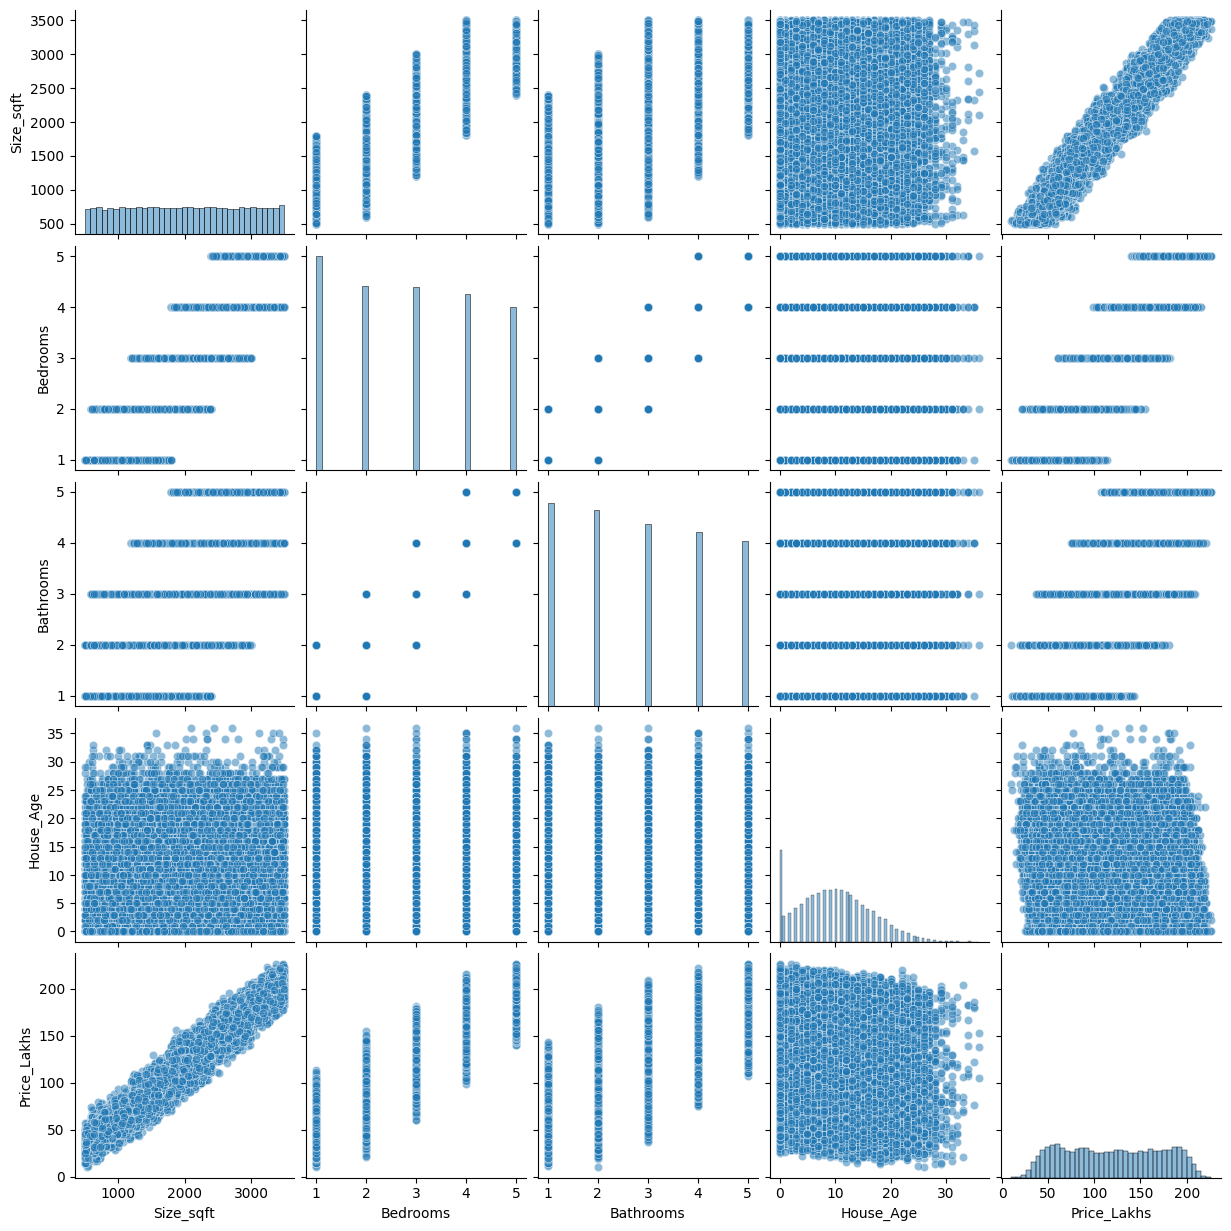

In [106]:
# EDA
sns.pairplot(
    df,
    kind='scatter',
    plot_kws={'alpha':0.5},
    diag_kws={'alpha':0.5}
)

## Building The Linear Regression Model

In [109]:
X = df[['Size_sqft', 'Bedrooms','Bathrooms','House_Age']]
y = df['Price_Lakhs']

In [145]:
X.head()
y.head()

0     87.1
1    101.4
2     79.2
3     95.7
4    126.0
Name: Price_Lakhs, dtype: float64

In [147]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [148]:
lr = LinearRegression()


In [149]:
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [150]:
lr.coef_

array([ 0.04493737,  6.03639833,  4.44998325, -0.5988078 ])

In [151]:
lr.score(X,y)

0.9866939690346972

In [152]:
cdf = pd.DataFrame(lr.coef_, X.columns, columns=['Coefficient'])
print(cdf)

           Coefficient
Size_sqft     0.044937
Bedrooms      6.036398
Bathrooms     4.449983
House_Age    -0.598808


In [153]:
predictions = lr.predict(X_test)

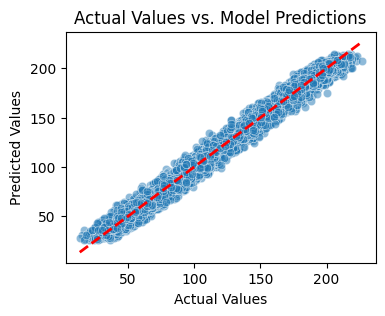

In [154]:
plt.figure(figsize=(4,3))
sns.scatterplot(x=y_test, y=predictions, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual Values vs. Model Predictions')
plt.show()


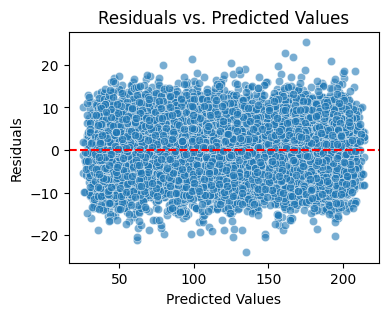

In [155]:
residuals = y_test - predictions

#residual plot
plt.figure(figsize=(4,3))
sns.scatterplot(x=predictions, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Values')
plt.show()

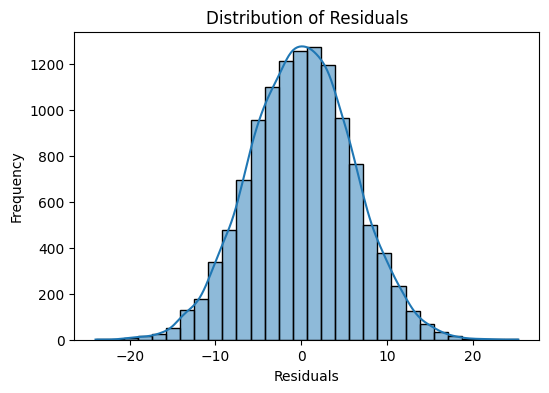

In [156]:
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True, bins=30)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.show()

## Model Accuracy Report

MODEL ACCURACY REPORT
R2 Score (Variance Explained): 98.67%
Accuracy : 94.75%

Mean Absolute Percentage Error (MAPE): 5.25%
Root Mean Squared Error:               $6.01
Mean Absolute Error:                   $4.80

Predictions within 5% of actual:      64.35%
Predictions within 10% of actual:     86.84%
Predictions within 20% of actual:     97.20%


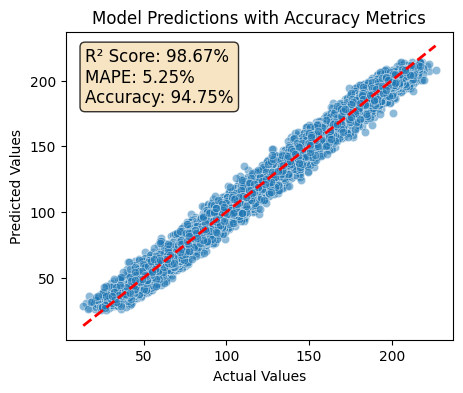

In [163]:
def model_accuracy_report(y_test, predictions):
    
    # R2 Score
    r2 = r2_score(y_test, predictions)
    
    # Mean Absolute Percentage Error
    mape = np.mean(np.abs((y_test - predictions) / y_test) * 100)
    
    # Accuracy Within Thresholds
    errors = np.abs((y_test - predictions) / y_test) * 100
    within_5 = np.mean(errors <= 5) * 100 
    within_10 = np.mean(errors <= 10) * 100
    within_20 = np.mean(errors <= 20) * 100

    # RMSE and MAE
    rmse = math.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)

    # Print the report
    print('=' * 60)
    print('MODEL ACCURACY REPORT')
    print('=' * 60)
    print(f'R2 Score (Variance Explained): {r2*100:.2f}%')
    print(f'Accuracy : {100 - mape:.2f}%')
    print(f'\nMean Absolute Percentage Error (MAPE): {mape:.2f}%')
    print(f"Root Mean Squared Error:               ${rmse:,.2f}")
    print(f"Mean Absolute Error:                   ${mae:,.2f}")
    print(f"\nPredictions within 5% of actual:      {within_5:.2f}%")
    print(f"Predictions within 10% of actual:     {within_10:.2f}%")
    print(f"Predictions within 20% of actual:     {within_20:.2f}%")
    print("=" * 60)

model_accuracy_report(y_test, predictions)

# Accuracy Plot
r2 = r2_score(y_test, predictions)
mape = np.mean(np.abs((y_test - predictions) / y_test)) * 100
fig,ax = plt.subplots(figsize=(5,4))

# Plot
sns.scatterplot(x=y_test, y=predictions, alpha=0.5, ax=ax)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

# Accuracy Test
textstr = f'R² Score: {r2*100:.2f}%\nMAPE: {mape:.2f}%\nAccuracy: {100-mape:.2f}%'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

ax.set_xlabel('Actual Values')
ax.set_ylabel('Predicted Values')
ax.set_title('Model Predictions with Accuracy Metrics')
plt.show()